# Machine Learning Techniques

## Lab 2: Launching an ML Workload on a Real-World Dataset


### Lab Objectives

- Upload and extract the project datasets in the Google Colab environment.
- Explore and profile a real-world cloud infrastructure dataset.
- Perform data preprocessing and feature engineering.
- Visualize the dataset using exploratory data analysis techniques.
- Train a baseline Decision Tree classifier.
- Evaluate the model using multiple performance metrics and visualizations.

## Importing Required Libraries

The following Python libraries are used throughout this experiment for data manipulation, visualization, preprocessing, and machine learning. These libraries collectively provide the necessary tools to build and evaluate a cloud infrastructure failure prediction model.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import glob
import zipfile

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

print("Required libraries imported successfully.")

Required libraries imported successfully.


## Uploading and Extracting the Project Datasets

The Cloud Infrastructure Failure Prediction System is developed using two real-world datasets. Both datasets are uploaded in compressed ZIP format and extracted into the Google Colab environment for further analysis.


In [ ]:
uploaded = files.upload()

Saving CIFPS - DATASET A.zip to CIFPS - DATASET A.zip
Saving CIFPS - DATASET B.zip to CIFPS - DATASET B.zip


In [ ]:
for zip_file in uploaded:
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall()

print("Datasets extracted successfully.")

Datasets extracted successfully.


## Configuring Dataset Paths

To improve code readability and maintainability, the root directories of Dataset A and Dataset B are defined. These paths will be reused throughout the notebook whenever data files are accessed.


In [ ]:
DATASET_A_PATH = "cloud-monitoring-dataset-master/data"
DATASET_B_PATH = "Failure-Dataset-OpenStack-main"

print("Dataset paths configured successfully.")

Dataset paths configured successfully.


## Discovering the Available Datasets

Dataset A contains multiple cloud infrastructure monitoring datasets collected from different application and system metrics. Before selecting a dataset for analysis, the available datasets are identified to understand the scope of the project and to choose an appropriate dataset for this laboratory experiment.

In [ ]:
dataset_a_files = sorted(
    glob.glob(f"{DATASET_A_PATH}/**/*.csv", recursive=True)
)

print(f"Total CSV files found in Dataset A: {len(dataset_a_files)}\n")

for index, file in enumerate(dataset_a_files, start=1):
    print(f"{index}. {os.path.relpath(file, DATASET_A_PATH)}")

Total CSV files found in Dataset A: 60

1. application-crash-rate-1/app1-01.csv
2. application-crash-rate-1/app1-02.csv
3. application-crash-rate-1/app1-03.csv
4. application-crash-rate-1/app1-04.csv
5. application-crash-rate-1/app1-05.csv
6. application-crash-rate-1/app1-06.csv
7. application-crash-rate-1/app1-07.csv
8. application-crash-rate-1/app1-08.csv
9. application-crash-rate-1/app1-09.csv
10. application-crash-rate-2/app2-01.csv
11. application-crash-rate-2/app2-02.csv
12. application-crash-rate-2/app2-03.csv
13. application-crash-rate-2/app2-04.csv
14. application-crash-rate-2/app2-05.csv
15. application-crash-rate-2/app2-06.csv
16. application-crash-rate-2/app2-07.csv
17. application-crash-rate-2/app2-08.csv
18. application-crash-rate-2/app2-09.csv
19. application-crash-rate-2/app2-10.csv
20. consumer-purchase-rate/purchase-01.csv
21. consumer-purchase-rate/purchase-02.csv
22. consumer-purchase-rate/purchase-03.csv
23. consumer-purchase-rate/purchase-04.csv
24. consumer-purch

## Selecting the Dataset

For this experiment, the **Application Crash Rate** dataset has been selected from Dataset A. This dataset contains application monitoring values and corresponding failure labels, making it suitable for demonstrating the complete machine learning workflow, including preprocessing, visualization, classification, and model evaluation.

In [ ]:
selected_dataset = os.path.join(
    DATASET_A_PATH,
    "application-crash-rate-1",
    "app1-01.csv"
)

print("Selected Dataset:\n")
print(selected_dataset)

Selected Dataset:

cloud-monitoring-dataset-master/data/application-crash-rate-1/app1-01.csv


## Loading the Selected Dataset

The selected cloud monitoring dataset is loaded into a Pandas DataFrame for further analysis. A copy of the original dataset is preserved to support time-series visualizations before preprocessing.

In [ ]:
raw_df = pd.read_csv(selected_dataset)

print("Dataset loaded successfully.")

display(raw_df.head())

Dataset loaded successfully.


,TimeStamp,Value,Label
0,2018-07-03 14:00:00,1,0
1,2018-07-03 15:00:00,0,0
2,2018-07-03 16:00:00,1,0
3,2018-07-03 17:00:00,1,0
4,2018-07-03 18:00:00,0,0


In [ ]:
analysis_df = raw_df.copy()

print("Working copy created successfully.")

Working copy created successfully.


## Dataset Profiling

Before applying machine learning techniques, it is essential to understand the structure and quality of the selected dataset. Dataset profiling provides an overview of the available features, data types, statistical properties, and data quality, helping identify any issues that may require preprocessing.

In [ ]:
print(f"Number of Rows    : {analysis_df.shape[0]}")
print(f"Number of Columns : {analysis_df.shape[1]}")

Number of Rows    : 358
Number of Columns : 3


In [ ]:
print("Column Names:\n")

for column in analysis_df.columns:
    print(f"• {column}")

Column Names:

• TimeStamp
• Value
• Label


In [ ]:
print("Data Types:\n")

display(analysis_df.dtypes)

Data Types:



,0
TimeStamp,object
Value,int64
Label,int64


In [ ]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   TimeStamp  358 non-null    object
 1   Value      358 non-null    int64 
 2   Label      358 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 8.5+ KB


In [ ]:
display(analysis_df.describe())

,Value,Label
count,358.000000,358.000000
mean,15.768156,0.111732
std,52.492703,0.315477
min,0.000000,0.000000
25%,3.000000,0.000000
50%,7.000000,0.000000
75%,12.000000,0.000000
max,492.000000,1.000000


In [ ]:
missing_values = analysis_df.isnull().sum()

missing_summary = pd.DataFrame({
    "Feature": missing_values.index,
    "Missing Values": missing_values.values
})

display(missing_summary)

,Feature,Missing Values
0,TimeStamp,0
1,Value,0
2,Label,0


In [ ]:
duplicate_records = analysis_df.duplicated().sum()

print(f"Duplicate Records Found : {duplicate_records}")

Duplicate Records Found : 11


In [ ]:
profile_summary = pd.DataFrame({
    "Property": [
        "Number of Records",
        "Number of Features",
        "Missing Values",
        "Duplicate Records"
    ],
    "Value": [
        analysis_df.shape[0],
        analysis_df.shape[1],
        analysis_df.isnull().sum().sum(),
        duplicate_records
    ]
})

display(profile_summary)

,Property,Value
0,Number of Records,358
1,Number of Features,3
2,Missing Values,0
3,Duplicate Records,11


## Data Preprocessing

Raw datasets often require preprocessing before they can be used for machine learning. In this experiment, the timestamp feature is converted into a datetime format, relevant temporal features are extracted, and the original timestamp column is removed to prepare the dataset for model training.

In [ ]:
model_df = analysis_df.copy()

print("Modeling dataset created successfully.")

Modeling dataset created successfully.


In [ ]:
model_df["TimeStamp"] = pd.to_datetime(model_df["TimeStamp"])

print("Timestamp converted successfully.")

display(model_df.head())

Timestamp converted successfully.


,TimeStamp,Value,Label
0,2018-07-03 14:00:00,1,0
1,2018-07-03 15:00:00,0,0
2,2018-07-03 16:00:00,1,0
3,2018-07-03 17:00:00,1,0
4,2018-07-03 18:00:00,0,0


In [ ]:
print("Updated Data Types:\n")

display(model_df.dtypes)

Updated Data Types:



,0
TimeStamp,datetime64[ns]
Value,int64
Label,int64


## Feature Engineering

Temporal information often contains useful patterns that can improve the predictive capability of machine learning models. The timestamp is decomposed into multiple numerical features, enabling the classifier to learn time-based behaviour from the monitoring data.

In [ ]:
model_df["Hour"] = model_df["TimeStamp"].dt.hour
model_df["Minute"] = model_df["TimeStamp"].dt.minute
model_df["Second"] = model_df["TimeStamp"].dt.second
model_df["DayOfWeek"] = model_df["TimeStamp"].dt.dayofweek
model_df["IsWeekend"] = model_df["DayOfWeek"].isin([5, 6]).astype(int)

display(model_df.head())

,TimeStamp,Value,Label,Hour,Minute,Second,DayOfWeek,IsWeekend
0,2018-07-03 14:00:00,1,0,14,0,0,1,0
1,2018-07-03 15:00:00,0,0,15,0,0,1,0
2,2018-07-03 16:00:00,1,0,16,0,0,1,0
3,2018-07-03 17:00:00,1,0,17,0,0,1,0
4,2018-07-03 18:00:00,0,0,18,0,0,1,0


In [ ]:
engineered_features = pd.DataFrame({
    "Engineered Feature": [
        "Hour",
        "Minute",
        "Second",
        "DayOfWeek",
        "IsWeekend"
    ],
    "Description": [
        "Hour extracted from timestamp",
        "Minute extracted from timestamp",
        "Second extracted from timestamp",
        "Day of the week (0 = Monday)",
        "Weekend indicator (1 = Weekend)"
    ]
})

## Preparing the Final Modeling Dataset

The original timestamp column is removed because machine learning algorithms cannot directly process datetime objects. The extracted numerical time features are retained for model training.

In [ ]:
model_df = model_df.drop(columns=["TimeStamp"])

print("Original timestamp removed successfully.")

display(model_df.head())

Original timestamp removed successfully.


,Value,Label,Hour,Minute,Second,DayOfWeek,IsWeekend
0,1,0,14,0,0,1,0
1,0,0,15,0,0,1,0
2,1,0,16,0,0,1,0
3,1,0,17,0,0,1,0
4,0,0,18,0,0,1,0


In [ ]:
print("Final Modeling Dataset")

display(model_df.info())

Final Modeling Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Value      358 non-null    int64
 1   Label      358 non-null    int64
 2   Hour       358 non-null    int32
 3   Minute     358 non-null    int32
 4   Second     358 non-null    int32
 5   DayOfWeek  358 non-null    int32
 6   IsWeekend  358 non-null    int64
dtypes: int32(4), int64(3)
memory usage: 14.1 KB


None

## Time Series Visualization

Time-series visualization helps understand how the monitored application values change over time. This plot is useful for identifying trends, sudden spikes, fluctuations, and unusual behaviour that may indicate abnormal system activity or application failures.

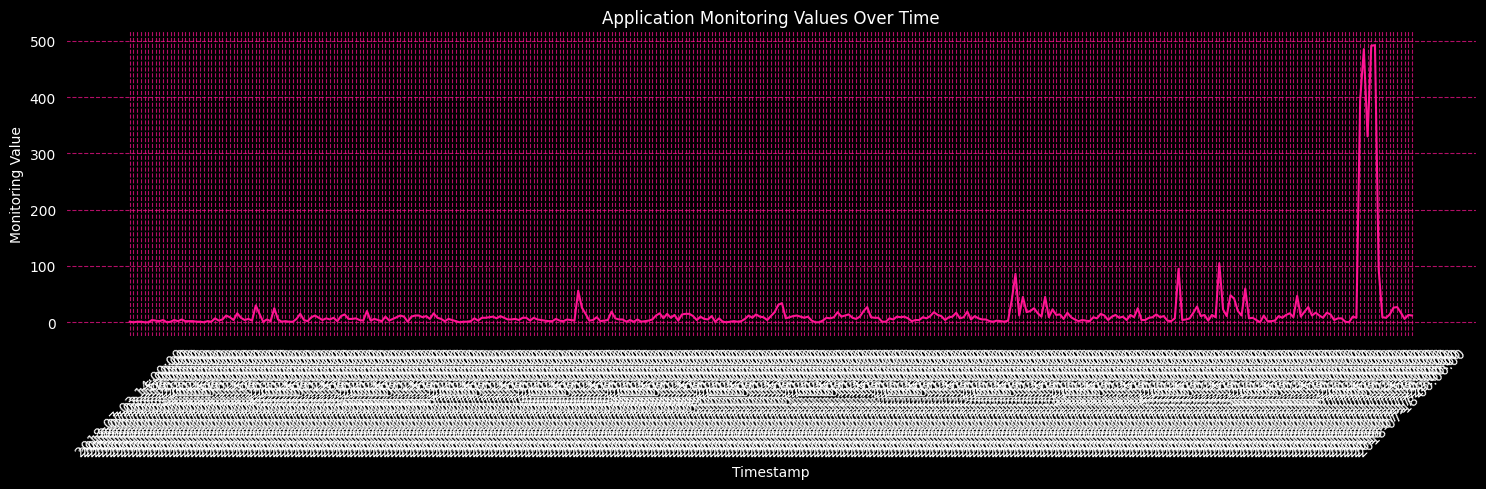

In [ ]:
plt.figure(figsize=(15,5), facecolor='black')

# Get the current axes and set its facecolor
ax = plt.gca()
ax.set_facecolor('black')

plt.plot(
    analysis_df["TimeStamp"],
    analysis_df["Value"],
    linewidth=1.5,
    color='deeppink'
)

plt.title("Application Monitoring Values Over Time", color='white')

plt.xlabel("Timestamp", color='white')

plt.ylabel("Monitoring Value", color='white')

plt.grid(True, color='deeppink', linestyle='--', alpha=0.7) # Set grid color to dark pink

plt.xticks(rotation=45, color='white') # Set x-axis tick label color
plt.yticks(color='white') # Set y-axis tick label color

plt.tight_layout()

plt.show()

## Rolling Mean Trend Analysis

A rolling mean smooths short-term fluctuations in the monitoring values, making long-term trends easier to observe. This visualization helps identify gradual increases or decreases in application behaviour while reducing the impact of random noise.

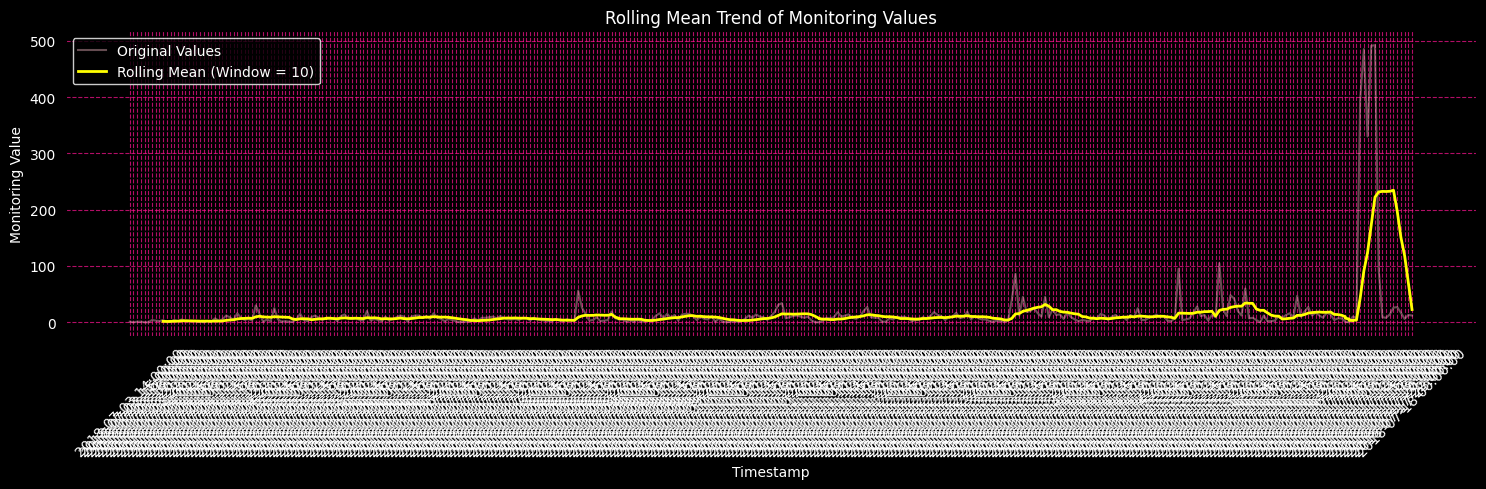

In [ ]:
rolling_mean = analysis_df["Value"].rolling(window=10).mean()

plt.figure(figsize=(15,5), facecolor='black')

# Get the current axes and set its facecolor
ax = plt.gca()
ax.set_facecolor('black')

plt.plot(
    analysis_df["TimeStamp"],
    analysis_df["Value"],
    alpha=0.4,
    label="Original Values",
    color='pink'
)

plt.plot(
    analysis_df["TimeStamp"],
    rolling_mean,
    linewidth=2,
    label="Rolling Mean (Window = 10)",
    color='yellow'
)

plt.title("Rolling Mean Trend of Monitoring Values", color='white')

plt.xlabel("Timestamp", color='white')

plt.ylabel("Monitoring Value", color='white')

# Update legend colors for better visibility on a dark background
legend = plt.legend(facecolor='black', edgecolor='white')
for text in legend.get_texts():
    text.set_color('white')

plt.grid(True, color='deeppink', linestyle='--', alpha=0.7)

plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

plt.tight_layout()

plt.show()

## Failure Event Timeline

This visualization distinguishes normal and failure events over time. By highlighting failure instances separately, it becomes easier to observe when abnormal application behaviour occurs within the monitoring timeline.

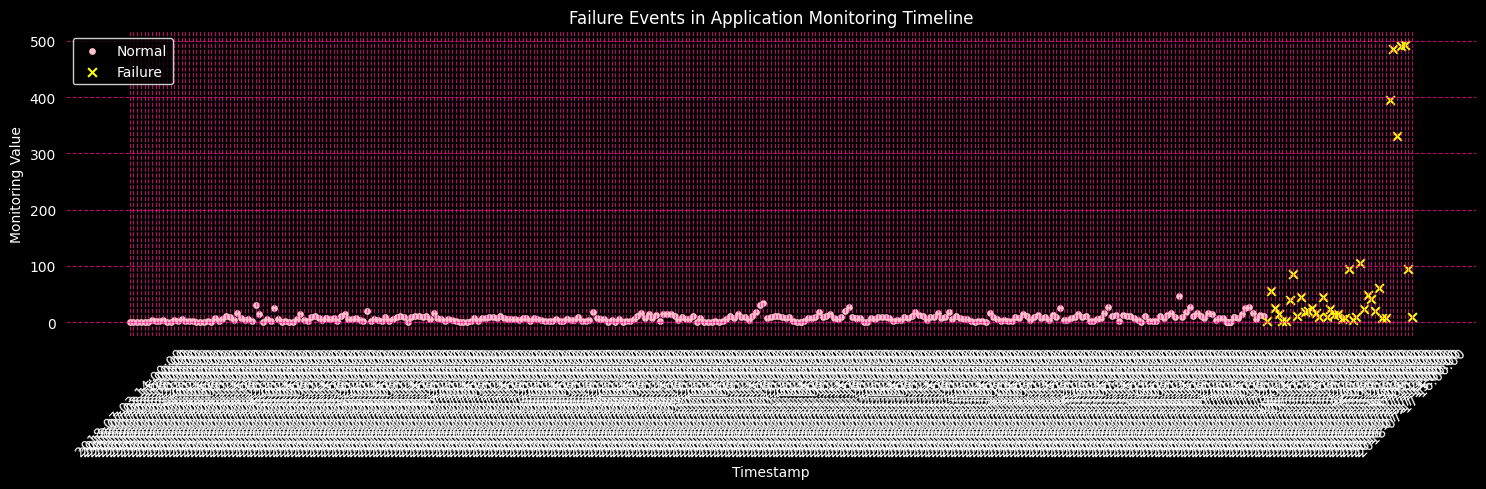

In [ ]:
plt.figure(figsize=(15,5), facecolor='black')

# Get the current axes and set its facecolor
ax = plt.gca()
ax.set_facecolor('black')

normal = analysis_df[analysis_df["Label"] == 0]
failure = analysis_df[analysis_df["Label"] == 1]

plt.scatter(
    normal["TimeStamp"],
    normal["Value"],
    s=15,
    label="Normal",
    color='pink'
)

plt.scatter(
    failure["TimeStamp"],
    failure["Value"],
    s=40,
    marker="x",
    label="Failure",
    color='yellow'
)

plt.title("Failure Events in Application Monitoring Timeline", color='white')

plt.xlabel("Timestamp", color='white')

plt.ylabel("Monitoring Value", color='white')

# Update legend colors for better visibility on a dark background
legend = plt.legend(facecolor='black', edgecolor='white')
for text in legend.get_texts():
    text.set_color('white')

plt.grid(True, color='deeppink', linestyle='--', alpha=0.7)

plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

plt.tight_layout()

plt.show()

## Relationship Between Hour of Day and Monitoring Value

Scatter plots are useful for examining relationships between two numerical variables. This visualization explores whether the monitoring values exhibit any noticeable variation across different hours of the day.

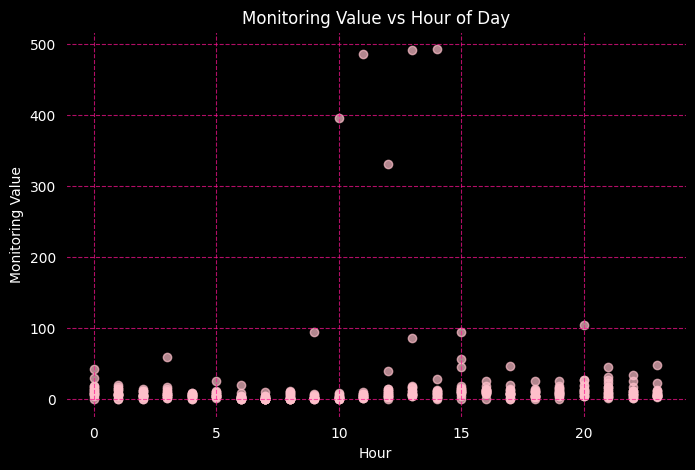

In [ ]:
plt.figure(figsize=(8,5), facecolor='black')

# Get the current axes and set its facecolor
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(
    model_df["Hour"],
    model_df["Value"],
    alpha=0.7,
    color='pink'
)

plt.title("Monitoring Value vs Hour of Day", color='white')

plt.xlabel("Hour", color='white')

plt.ylabel("Monitoring Value", color='white')

plt.grid(True, color='deeppink', linestyle='--', alpha=0.7)

plt.xticks(color='white')
plt.yticks(color='white')

plt.show()

## Outlier Detection Using a Box Plot

A box plot summarizes the distribution of monitoring values by displaying the median, quartiles, and potential outliers. This visualization is particularly useful for identifying unusually high or low observations that may correspond to abnormal system behaviour.

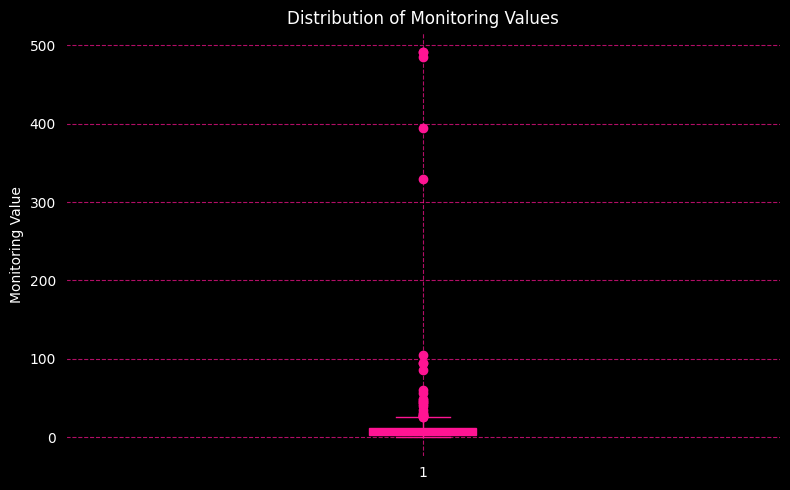

In [ ]:
plt.figure(figsize=(8,5), facecolor='black')

# Get the current axes and set its facecolor
ax = plt.gca()
ax.set_facecolor('black')

plt.boxplot(
    model_df["Value"],
    vert=True,
    patch_artist=True, # Enable coloring of the box with facecolor
    boxprops=dict(facecolor='deeppink', edgecolor='deeppink'), # Darkest pink box
    medianprops=dict(color='deeppink'), # Darkest pink median line
    whiskerprops=dict(color='deeppink'), # Darkest pink whiskers
    capprops=dict(color='deeppink'), # Darkest pink caps
    flierprops=dict(marker='o', markerfacecolor='deeppink', markeredgecolor='deeppink') # Darkest pink outliers
)

plt.title("Distribution of Monitoring Values", color='white') # White title

plt.xlabel("", color='white') # Set x-axis label color to white (empty label for single box plot)
plt.ylabel("Monitoring Value", color='white') # White y-axis label

plt.grid(True, color='deeppink', linestyle='--', alpha=0.7) # Dark pink grid lines

plt.xticks(color='white') # White x-axis tick labels
plt.yticks(color='white') # White y-axis tick labels

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

## Distribution of Application Status

Before training a classification model, it is important to understand how the target classes are distributed. This bar chart illustrates the number of normal and failure observations in the dataset, helping identify whether the dataset is balanced or imbalanced.

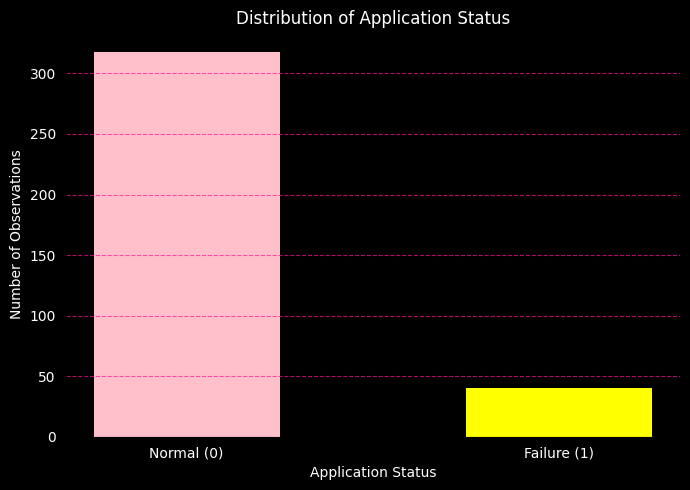

In [ ]:
label_counts = model_df["Label"].value_counts().sort_index()

status = ["Normal (0)", "Failure (1)"]

plt.figure(figsize=(7,5), facecolor='black')

# Get the current axes and set its facecolor
ax = plt.gca()
ax.set_facecolor('black')

plt.bar(
    status,
    label_counts.values,
    width=0.5,
    color=['pink', 'yellow'] # Set colors for Normal and Failure
)

plt.title("Distribution of Application Status", color='white') # White title

plt.xlabel("Application Status", color='white') # White x-axis label

plt.ylabel("Number of Observations", color='white') # White y-axis label

plt.grid(axis="y", color='deeppink', linestyle='--', alpha=0.7) # Dark pink grid lines

plt.xticks(color='white') # White x-axis tick labels
plt.yticks(color='white') # White y-axis tick labels

plt.tight_layout() # Adjust layout

plt.show()

## Correlation Matrix

The correlation matrix measures the strength and direction of relationships between numerical features. Positive values indicate direct relationships, while negative values indicate inverse relationships. This analysis helps identify features that are strongly associated with each other.

In [ ]:
correlation_matrix = model_df.corr(numeric_only=True)

display(correlation_matrix)

,Value,Label,Hour,Minute,Second,DayOfWeek,IsWeekend
Value,1.000000,0.436615,0.046158,NaN,NaN,-0.099290,-0.062538
Label,0.436615,1.000000,0.072007,NaN,NaN,0.135323,0.080542
Hour,0.046158,0.072007,1.000000,NaN,NaN,-0.007690,-0.004227
Minute,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Second,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DayOfWeek,-0.099290,0.135323,-0.007690,NaN,NaN,1.000000,0.795588
IsWeekend,-0.062538,0.080542,-0.004227,NaN,NaN,0.795588,1.000000


## Correlation Heatmap

The correlation heatmap provides a graphical representation of the relationships between numerical features. Darker shades indicate stronger correlations, making it easier to identify patterns and dependencies among the cloud monitoring metrics.

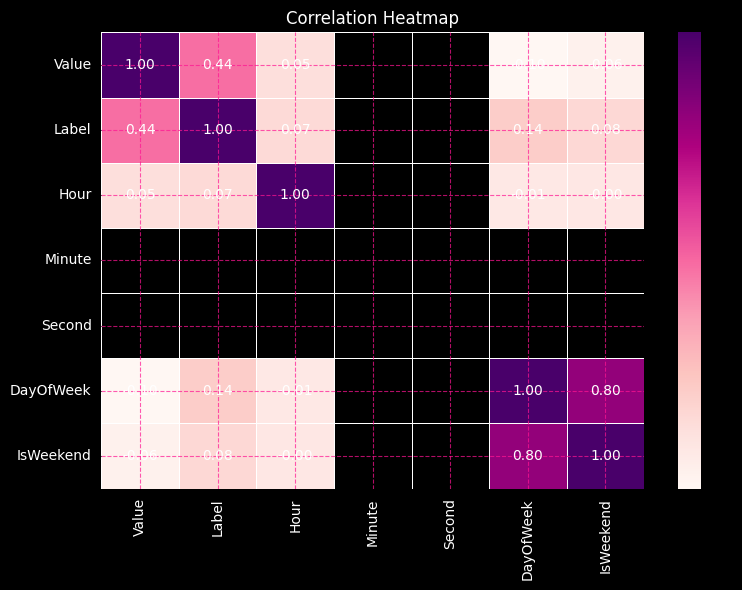

In [ ]:
plt.figure(figsize=(8,6), facecolor='black')

# Get the current axes and set its facecolor
ax = plt.gca()
ax.set_facecolor('black')

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdPu", # Changed colormap to pinkish tones
    linewidths=0.5,
    fmt=".2f",
    annot_kws={"color": "white"} # Set annotation text color to white
)

plt.title("Correlation Heatmap", color='white') # Set title color to white

plt.xticks(color='white') # Set x-axis tick label color to white
plt.yticks(color='white') # Set y-axis tick label color to white

# Add grid lines for consistency, though less common for heatmaps in the main plot area
plt.grid(True, color='deeppink', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

## Failure Frequency Across Different Hours

The following visualization analyzes the occurrence of application failures throughout the day. Understanding the temporal distribution of failures can help identify periods during which the cloud infrastructure experiences a higher likelihood of abnormal behaviour.

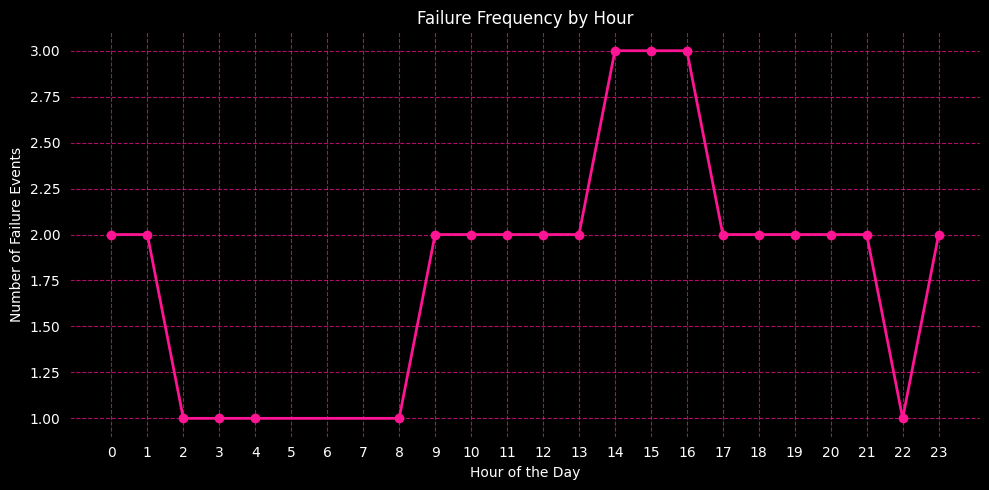

In [ ]:
failure_data = model_df[model_df["Label"] == 1]

failure_by_hour = (
    failure_data.groupby("Hour")
    .size()
    .reset_index(name="Failure Count")
)

plt.figure(figsize=(10,5), facecolor='black') # Set figure facecolor to black

# Get the current axes and set its facecolor
ax = plt.gca()
ax.set_facecolor('black')

plt.plot(
    failure_by_hour["Hour"],
    failure_by_hour["Failure Count"],
    marker="o",
    linewidth=2,
    color='deeppink' # Set line color to dark pink
)

plt.title("Failure Frequency by Hour", color='white') # Set title color to white

plt.xlabel("Hour of the Day", color='white') # Set x-axis label color to white

plt.ylabel("Number of Failure Events", color='white') # Set y-axis label color to white

plt.xticks(range(0,24), color='white') # Set x-axis tick label color to white
plt.yticks(color='white') # Set y-axis tick label color to white

plt.grid(True, color='deeppink', linestyle='--', alpha=0.7) # Set grid color to dark pink

plt.tight_layout()

plt.show()

## Feature Selection

Feature selection is the process of identifying the predictor variables (features) and the target variable required for model training. In this experiment, the engineered cloud monitoring features are used as input variables, while the **Label** column is selected as the target variable representing the application status.

In [ ]:
X = model_df.drop(columns=["Label"])
y = model_df["Label"]

print("Input Feature Matrix (X)")
display(X.head())

print("Target Variable (y)")
display(y.head())

Input Feature Matrix (X)


,Value,Hour,Minute,Second,DayOfWeek,IsWeekend
0,1,14,0,0,1,0
1,0,15,0,0,1,0
2,1,16,0,0,1,0
3,1,17,0,0,1,0
4,0,18,0,0,1,0


Target Variable (y)


,Label
0,0
1,0
2,0
3,0
4,0


## Splitting the Dataset

To evaluate the machine learning model fairly, the dataset is divided into training and testing subsets. The model is trained using the training data and its performance is evaluated on previously unseen testing data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

summary = pd.DataFrame({
    "Dataset": [
        "Training Features",
        "Testing Features",
        "Training Labels",
        "Testing Labels"
    ],
    "Shape": [
        str(X_train.shape),
        str(X_test.shape),
        str(y_train.shape),
        str(y_test.shape)
    ]
})

display(summary)

,Dataset,Shape
0,Training Features,"(286, 6)"
1,Testing Features,"(72, 6)"
2,Training Labels,"(286,)"
3,Testing Labels,"(72,)"


## Training the Decision Tree Classifier

A Decision Tree is a supervised machine learning algorithm capable of learning decision rules from historical observations. The classifier is trained using the prepared cloud monitoring dataset to distinguish between normal and failure conditions.

In [ ]:
decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## Generating Predictions

After training, the Decision Tree classifier is applied to the testing dataset to predict the application status. These predictions are compared with the actual labels during model evaluation.

In [ ]:
y_pred = decision_tree.predict(X_test)

prediction_results = pd.DataFrame({
    "Actual Label": y_test.values,
    "Predicted Label": y_pred
})

display(prediction_results.head(15))

,Actual Label,Predicted Label
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,1,1
7,0,0
8,0,0
9,1,1


## Prediction Summary

The following table summarizes the number of observations predicted for each application status. This provides a quick overview of the classifier's prediction distribution before performing detailed performance evaluation.

In [ ]:
prediction_summary = pd.DataFrame({
    "Predicted Class": pd.Series(y_pred).value_counts().index,
    "Count": pd.Series(y_pred).value_counts().values
})

display(prediction_summary)

,Predicted Class,Count
0,0,65
1,1,7


## Model Evaluation

Model evaluation measures how effectively the trained Decision Tree classifier predicts application failures on unseen data. Multiple evaluation metrics are used to provide a comprehensive assessment of the classifier's predictive performance.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, decision_tree.predict_proba(X_test)[:,1])

evaluation_metrics = pd.DataFrame({
    "Evaluation Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC Score"
    ],
    "Score": [
        round(accuracy,4),
        round(precision,4),
        round(recall,4),
        round(f1,4),
        round(roc_auc,4)
    ]
})

display(evaluation_metrics)

,Evaluation Metric,Score
0,Accuracy,0.9028
1,Precision,0.5714
2,Recall,0.5000
3,F1 Score,0.5333
4,ROC-AUC Score,0.7666


## Classification Report

The classification report provides a detailed evaluation of the classifier by reporting Precision, Recall, F1-Score, and Support for each class. These metrics offer deeper insight into the model's ability to correctly identify both normal and failure events.

In [ ]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

classification_df = pd.DataFrame(report).transpose()

display(classification_df)

,precision,recall,f1-score,support
0,0.938462,0.953125,0.945736,64.000000
1,0.571429,0.500000,0.533333,8.000000
accuracy,0.902778,0.902778,0.902778,0.902778
macro avg,0.754945,0.726562,0.739535,72.000000
weighted avg,0.897680,0.902778,0.899914,72.000000


## Confusion Matrix

The confusion matrix summarizes the classification performance by comparing the predicted labels with the actual labels. It indicates the number of correct predictions as well as the different types of classification errors made by the model.

In [ ]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Normal","Actual Failure"],
    columns=["Predicted Normal","Predicted Failure"]
)

display(cm_df)

,Predicted Normal,Predicted Failure
Actual Normal,61,3
Actual Failure,4,4


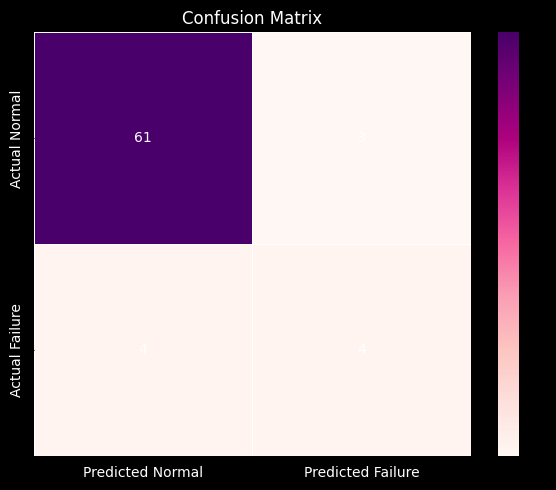

In [ ]:
plt.figure(figsize=(6,5), facecolor='black')

# Get the current axes and set its facecolor
ax = plt.gca()
ax.set_facecolor('black')

sns.heatmap(
    cm_df,
    annot=True,
    cmap="RdPu", # Changed colormap to pinkish tones for consistency
    fmt="d",
    linewidths=0.5,
    annot_kws={"color": "white"} # Set annotation text color to white
)

plt.title("Confusion Matrix", color='white') # Set title color to white

plt.xticks(color='white') # Set x-axis tick label color to white
plt.yticks(color='white') # Set y-axis tick label color to white

plt.tight_layout()

plt.show()

## Receiver Operating Characteristic (ROC) Curve

The ROC Curve illustrates the ability of the Decision Tree classifier to distinguish between normal and failure events across different classification thresholds. The Area Under the Curve (ROC-AUC) provides an overall measure of classification performance.

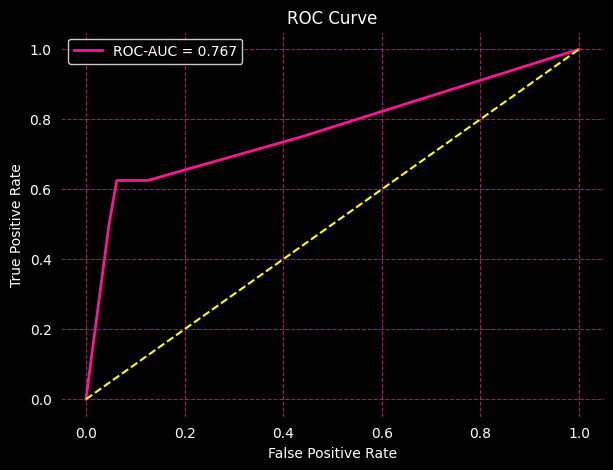

In [ ]:
probabilities = decision_tree.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(7,5), facecolor='black')

# Get the current axes and set its facecolor
ax = plt.gca()
ax.set_facecolor('black')

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC-AUC = {roc_auc:.3f}",
    color='deeppink' # Set ROC curve color to deeppink
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color='yellow' # Set random classifier line color to yellow
)

plt.xlabel("False Positive Rate", color='white') # Set x-axis label color to white

plt.ylabel("True Positive Rate", color='white') # Set y-axis label color to white

plt.title("ROC Curve", color='white') # Set title color to white

# Update legend colors for better visibility on a dark background
legend = plt.legend(facecolor='black', edgecolor='white')
for text in legend.get_texts():
    text.set_color('white')

plt.grid(True, color='deeppink', linestyle='--', alpha=0.7) # Set grid color to dark pink

plt.xticks(color='white') # Set x-axis tick label color to white
plt.yticks(color='white') # Set y-axis tick label color to white

plt.show()

## Decision Tree Visualization

Visualizing the trained Decision Tree provides insight into the sequence of decision rules learned during training. Each internal node represents a decision based on one of the input features, while the leaf nodes represent the predicted application status.

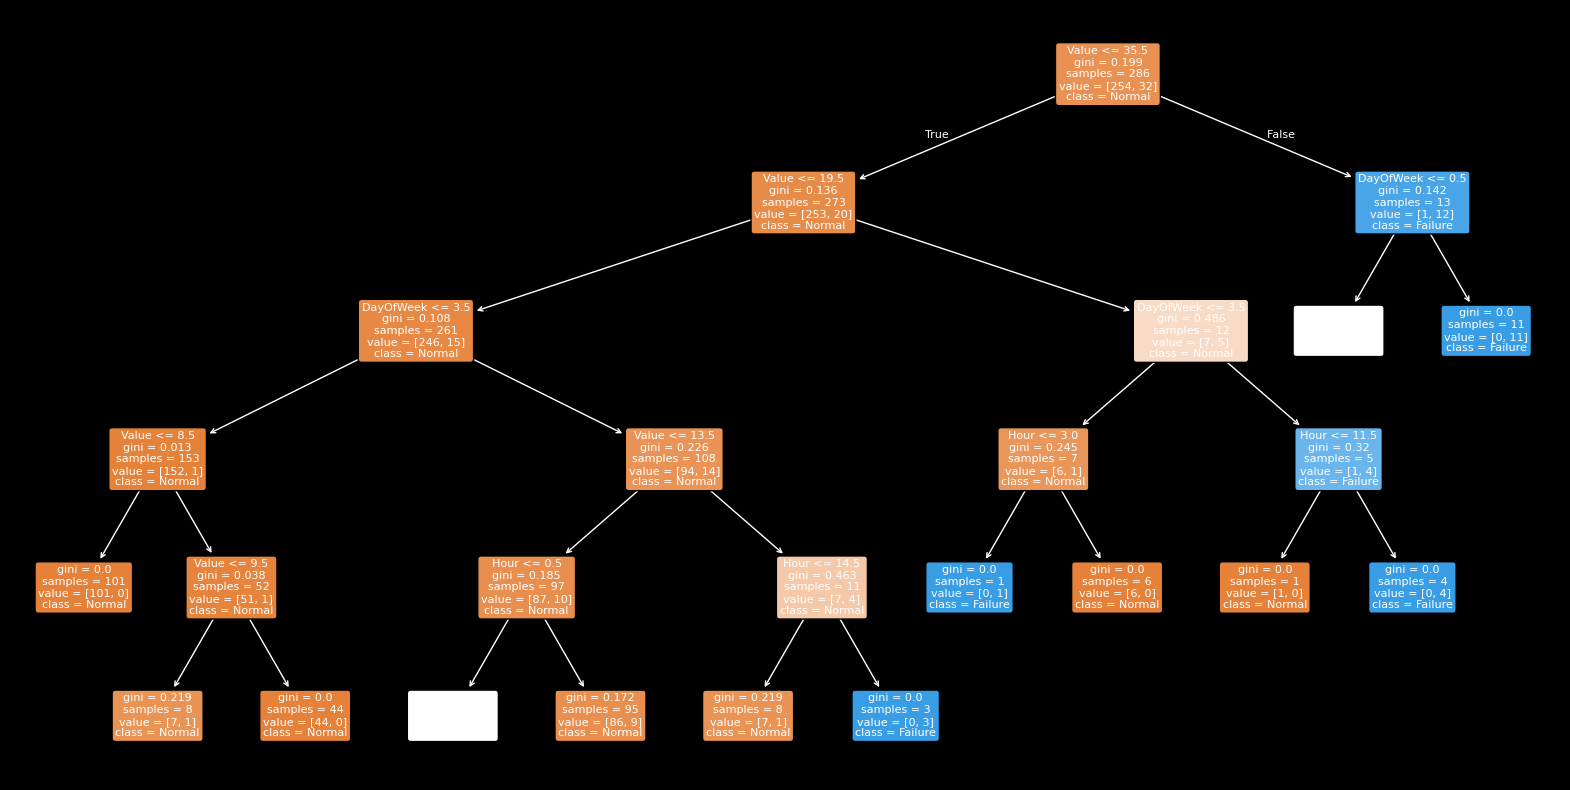

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set global text color to white for better visibility on black background
plt.rcParams['text.color'] = 'white'
# Set global line color to white to make arrows visible
plt.rcParams['lines.color'] = 'white'
# Set axes edge color to white for consistency
plt.rcParams['axes.edgecolor'] = 'white'
# Set tick colors to white for consistency, though not directly visible in plot_tree
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

plt.figure(figsize=(20,10), facecolor='black') # Set figure facecolor to black

# Get the current axes and set its facecolor
ax = plt.gca()
ax.set_facecolor('black')

# Removed cmap=pink_yellow_cmap as it's not supported by this version of plot_tree
plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=["Normal","Failure"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

## Feature Importance Analysis

Feature importance measures the contribution of each feature towards the model's predictions. Features with higher importance values have a greater influence on identifying application failures.

In [ ]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
0,Value,0.640960
1,Hour,0.208267
4,DayOfWeek,0.150773
2,Minute,0.000000
3,Second,0.000000
5,IsWeekend,0.000000


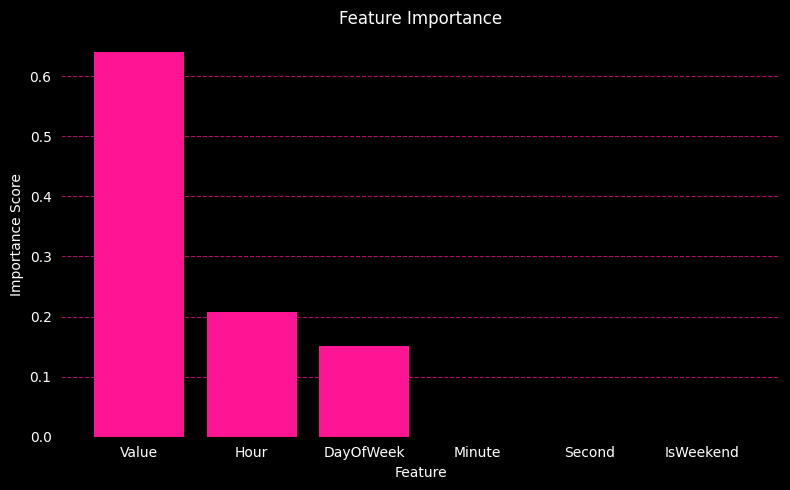

In [ ]:
plt.figure(figsize=(8,5), facecolor='black')

# Get the current axes and set its facecolor
ax = plt.gca()
ax.set_facecolor('black')

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"],
    color='deeppink' # Set bar color to deeppink
)

plt.title("Feature Importance", color='white') # Set title color to white

plt.xlabel("Feature", color='white') # Set x-axis label color to white

plt.ylabel("Importance Score", color='white') # Set y-axis label color to white

plt.grid(axis="y", color='deeppink', linestyle='--', alpha=0.7) # Set grid color to dark pink

plt.xticks(color='white') # Set x-axis tick label color to white
plt.yticks(color='white') # Set y-axis tick label color to white

plt.tight_layout()

plt.show()

## Actual vs Predicted Application Status

The following visualization compares the actual application status with the predictions generated by the Decision Tree classifier. It provides a clear indication of where the model correctly identifies failure events and where prediction errors occur.

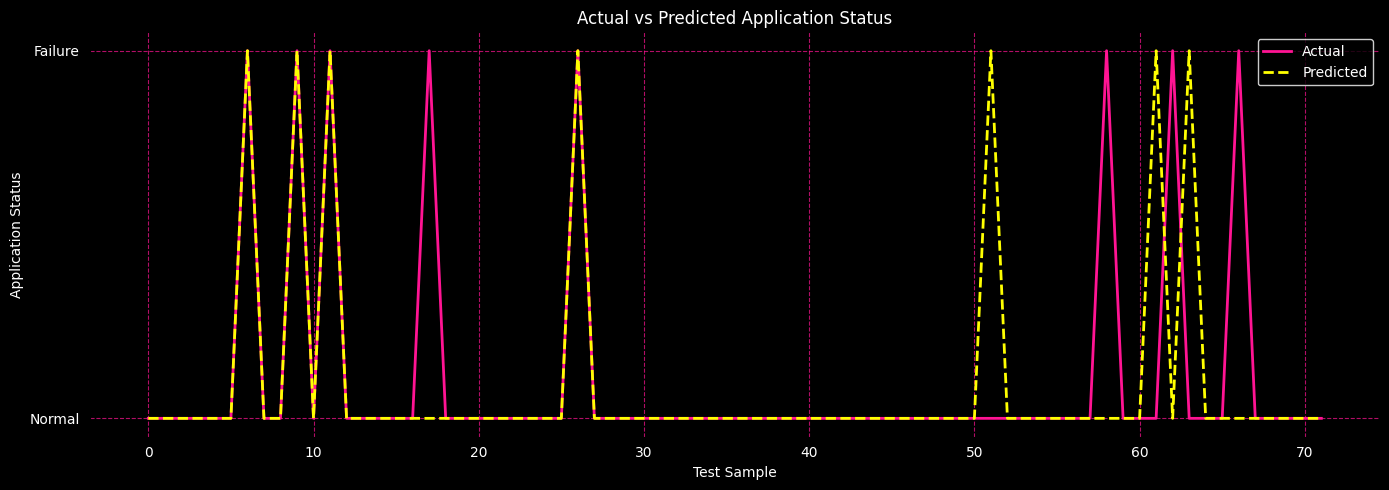

In [ ]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

plt.figure(figsize=(14,5), facecolor='black')

# Get the current axes and set its facecolor
ax = plt.gca()
ax.set_facecolor('black')

plt.plot(
    comparison_df.index,
    comparison_df["Actual"],
    label="Actual",
    linewidth=2,
    color='deeppink' # Set actual line color to deeppink
)

plt.plot(
    comparison_df.index,
    comparison_df["Predicted"],
    linestyle="--",
    linewidth=2,
    label="Predicted",
    color='yellow' # Set predicted line color to yellow
)

plt.title("Actual vs Predicted Application Status", color='white') # Set title color to white

plt.xlabel("Test Sample", color='white') # Set x-axis label color to white

plt.ylabel("Application Status", color='white') # Set y-axis label color to white

plt.yticks([0,1],["Normal","Failure"], color='white') # Set y-axis tick labels and color
plt.xticks(color='white') # Set x-axis tick label color to white

# Update legend colors for better visibility on a dark background
legend = plt.legend(facecolor='black', edgecolor='white')
for text in legend.get_texts():
    text.set_color('white')

plt.grid(True, color='deeppink', linestyle='--', alpha=0.7) # Set grid color to dark pink

plt.tight_layout()

plt.show()

## Model Interpretation

The Decision Tree classifier demonstrated its ability to distinguish between normal and failure events using the selected cloud monitoring features. The evaluation metrics indicate the overall predictive capability of the model, while the confusion matrix highlights the correctly classified instances and the remaining classification errors. Feature importance analysis reveals which monitoring attributes contribute most to the prediction process, providing valuable insight into the behaviour of the cloud infrastructure. Although the model performs well on the selected dataset, its effectiveness can be further enhanced by incorporating additional monitoring metrics and larger datasets in future experiments.

## Key Observations

- The selected dataset was successfully preprocessed and transformed into a machine learning-ready format.
- Temporal information extracted from the timestamp provided additional predictive features.
- Exploratory Data Analysis revealed the behaviour and distribution of the cloud monitoring data through multiple visualizations.
- The Decision Tree classifier successfully learned patterns associated with application failures.
- Multiple evaluation metrics, including Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score, were used to assess model performance.
- Feature importance analysis helped identify the variables that contributed most to the classification process.
- The implemented workflow establishes a strong baseline for more advanced machine learning models in future laboratory experiments.

## Conclusion

In this laboratory experiment, a complete machine learning workflow was successfully implemented using a real-world cloud infrastructure monitoring dataset. The dataset was uploaded, explored, profiled, preprocessed, and analyzed through multiple exploratory visualizations before training a Decision Tree classifier. The trained model was evaluated using several performance metrics, including Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, Classification Report, and Confusion Matrix. Additional visualizations such as the ROC Curve, Decision Tree structure, Feature Importance, and Actual vs Predicted comparison further enhanced the interpretability of the model. Overall, the experiment successfully demonstrated the process of launching and evaluating a machine learning workload on a real-world dataset while establishing a solid foundation for subsequent laboratory exercises.


In [ ]:
completion_checklist = pd.DataFrame({
    "Task": [
        "Imported required libraries",
        "Uploaded project datasets",
        "Extracted ZIP archives",
        "Configured dataset paths",
        "Discovered available datasets",
        "Selected cloud monitoring dataset",
        "Loaded dataset successfully",
        "Performed dataset profiling",
        "Completed data preprocessing",
        "Engineered temporal features",
        "Performed exploratory data analysis",
        "Built Decision Tree classifier",
        "Generated predictions",
        "Evaluated model performance",
        "Visualized model results",
        "Interpreted experimental results"
    ],
    "Status": ["✓ Completed"] * 16
})

display(completion_checklist)

,Task,Status
0,Imported required libraries,✓ Completed
1,Uploaded project datasets,✓ Completed
2,Extracted ZIP archives,✓ Completed
3,Configured dataset paths,✓ Completed
4,Discovered available datasets,✓ Completed
5,Selected cloud monitoring dataset,✓ Completed
6,Loaded dataset successfully,✓ Completed
7,Performed dataset profiling,✓ Completed
8,Completed data preprocessing,✓ Completed
9,Engineered temporal features,✓ Completed
